In [1]:
!pip install nltk textblob wordcloud

In [5]:
import pandas as pd
import nltk
import string

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from textblob import TextBlob

import matplotlib.pyplot as plt
from wordcloud import WordCloud

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [6]:
comments = [
    "This product is amazing!",
    "I really love the quality.",
    "Worst purchase ever.",
    "Very disappointed with the service.",
    "Excellent customer support.",
    "The delivery was too late.",
    "Fantastic experience!",
    "Not worth the money.",
    "Highly recommended.",
    "The packaging was damaged.",
    "Good value for money.",
    "I hate this product.",
    "Very satisfied with my purchase.",
    "Awesome quality and fast delivery.",
    "Poor customer service."
]

df = pd.DataFrame(comments, columns=["Comment"])

df.head()

,Comment
0,This product is amazing!
1,I really love the quality.
2,Worst purchase ever.
3,Very disappointed with the service.
4,Excellent customer support.


In [9]:
stop_words = set(stopwords.words("english"))

def clean_text(text):

    text = text.lower()

    text = text.translate(str.maketrans('', '', string.punctuation))

    words = word_tokenize(text)

    words = [word for word in words if word not in stop_words]

    return " ".join(words)

df["Cleaned_Comment"] = df["Comment"].apply(clean_text)

def get_sentiment(text):

    polarity = TextBlob(text).sentiment.polarity

    if polarity > 0:
        return "Positive"

    elif polarity < 0:
        return "Negative"

    else:
        return "Neutral"

df["Sentiment"] = df["Cleaned_Comment"].apply(get_sentiment)

df

,Comment,Cleaned_Comment,Sentiment
0,This product is amazing!,product amazing,Positive
1,I really love the quality.,really love quality,Positive
2,Worst purchase ever.,worst purchase ever,Negative
3,Very disappointed with the service.,disappointed service,Negative
4,Excellent customer support.,excellent customer support,Positive
5,The delivery was too late.,delivery late,Negative
6,Fantastic experience!,fantastic experience,Positive
7,Not worth the money.,worth money,Positive
8,Highly recommended.,highly recommended,Positive
9,The packaging was damaged.,packaging damaged,Neutral


In [10]:
print(df["Sentiment"].value_counts())

Sentiment
Positive    9
Negative    5
Neutral     1
Name: count, dtype: int64


In [11]:
sentiment_percentages = df["Sentiment"].value_counts(normalize=True) * 100
print(sentiment_percentages)

Sentiment
Positive    60.000000
Negative    33.333333
Neutral      6.666667
Name: proportion, dtype: float64


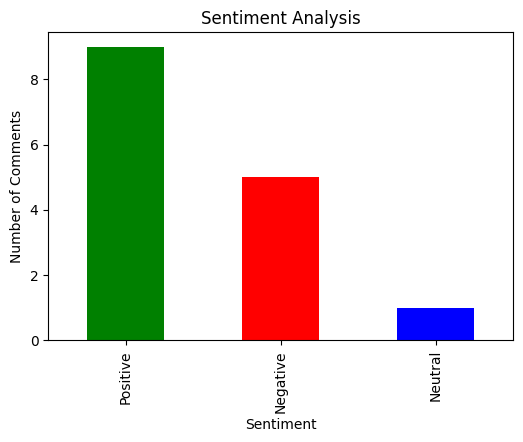

In [12]:
df["Sentiment"].value_counts().plot(
    kind="bar",
    color=["green","red","blue"],
    figsize=(6,4)
)

plt.title("Sentiment Analysis")
plt.xlabel("Sentiment")
plt.ylabel("Number of Comments")
plt.show()

In [13]:
all_words = " ".join(df["Cleaned_Comment"])

word_list = all_words.split()

word_freq = pd.Series(word_list).value_counts()

print(word_freq.head(10))

product     2
quality     2
customer    2
delivery    2
service     2
purchase    2
money       2
worst       1
really      1
love        1
Name: count, dtype: int64


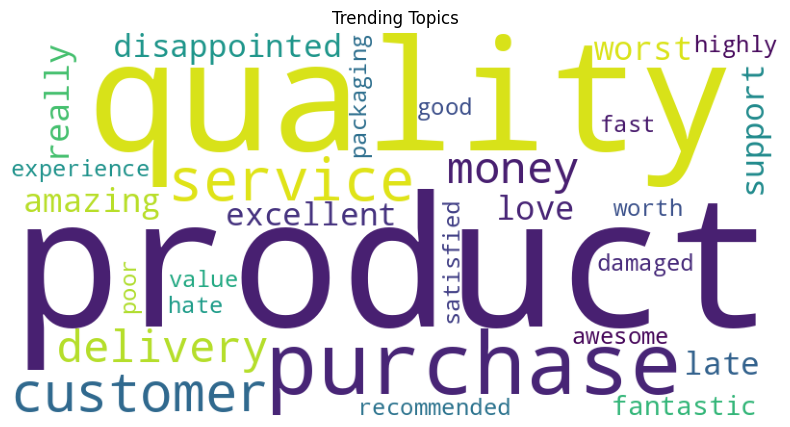

In [14]:
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(all_words)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Trending Topics")
plt.show()

In [15]:
print(df)

                                Comment                Cleaned_Comment  \
0              This product is amazing!                product amazing   
1            I really love the quality.            really love quality   
2                  Worst purchase ever.            worst purchase ever   
3   Very disappointed with the service.           disappointed service   
4           Excellent customer support.     excellent customer support   
5            The delivery was too late.                  delivery late   
6                 Fantastic experience!           fantastic experience   
7                  Not worth the money.                    worth money   
8                   Highly recommended.             highly recommended   
9            The packaging was damaged.              packaging damaged   
10                Good value for money.               good value money   
11                 I hate this product.                   hate product   
12     Very satisfied with my purchase